In [1]:
# Import Libraries and Data Load
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('online_retail.csv')

In [2]:
df.shape

(541909, 8)

In [3]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [4]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01/12/2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01/12/2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01/12/2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01/12/2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01/12/2010 08:26,3.39,17850.0,United Kingdom


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 67.8 MB


In [6]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


## Data Cleaning

In [7]:
# Rename columns according to snake casing for better readability and documentation
df = df.rename(columns={
    'InvoiceNo': 'invoice_no',
    'StockCode': 'stock_code',
    'Description': 'product_name',
    'Quantity': 'quantity',
    'InvoiceDate': 'invoice_date',
    'UnitPrice': 'unit_price',
    'CustomerID': 'customer_id',
    'Country': 'country'
})
df

,invoice_no,stock_code,product_name,quantity,invoice_date,unit_price,customer_id,country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01/12/2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01/12/2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01/12/2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01/12/2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01/12/2010 08:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,09/12/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,09/12/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,09/12/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,09/12/2011 12:50,4.15,12680.0,France


In [8]:
# Check for null values
df.isnull().sum()

invoice_no           0
stock_code           0
product_name      1454
quantity             0
invoice_date         0
unit_price           0
customer_id     135080
country              0
dtype: int64

In [9]:
# Find Percentage of NaN values per column
(df.isna().sum() / len(df) * 100).round(2)   

invoice_no       0.00
stock_code       0.00
product_name     0.27
quantity         0.00
invoice_date     0.00
unit_price       0.00
customer_id     24.93
country          0.00
dtype: float64

In [10]:
# Convert invoice_date to datetime
df['invoice_date'] = pd.to_datetime(df['invoice_date'], dayfirst=True)   
df[['invoice_no', 'invoice_date']].sample(7)

,invoice_no,invoice_date
355816,567972,2011-09-23 10:14:00
88555,543807,2011-02-13 13:15:00
202936,554511,2011-05-24 15:52:00
330724,565922,2011-09-08 09:51:00
384257,570114,2011-10-07 12:31:00
344287,567024,2011-09-16 11:23:00
376807,569535,2011-10-04 15:41:00


In [11]:
# Remove cancellations (InvoiceNo starts with 'C')
df = df[~df['invoice_no'].astype(str).str.startswith('C')]
df.shape

(532621, 8)

In [12]:
# Remove invalid quantities 
df = df[df['quantity'] > 0]
df[['invoice_no','product_name', 'quantity']]

,invoice_no,product_name,quantity
0,536365,WHITE HANGING HEART T-LIGHT HOLDER,6
1,536365,WHITE METAL LANTERN,6
2,536365,CREAM CUPID HEARTS COAT HANGER,8
3,536365,KNITTED UNION FLAG HOT WATER BOTTLE,6
4,536365,RED WOOLLY HOTTIE WHITE HEART.,6
...,...,...,...
541904,581587,PACK OF 20 SPACEBOY NAPKINS,12
541905,581587,CHILDREN'S APRON DOLLY GIRL,6
541906,581587,CHILDRENS CUTLERY DOLLY GIRL,4
541907,581587,CHILDRENS CUTLERY CIRCUS PARADE,4


In [13]:
# Remove rows with missing customer_id 
df = df[df['customer_id'].notna()]
df.shape

(397924, 8)

In [14]:
# Remove rows with Invalid UnitPrice
df = df[df['unit_price'] > 0]
df[['product_name','quantity', 'unit_price']]

,product_name,quantity,unit_price
0,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55
1,WHITE METAL LANTERN,6,3.39
2,CREAM CUPID HEARTS COAT HANGER,8,2.75
3,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39
4,RED WOOLLY HOTTIE WHITE HEART.,6,3.39
...,...,...,...
541904,PACK OF 20 SPACEBOY NAPKINS,12,0.85
541905,CHILDREN'S APRON DOLLY GIRL,6,2.10
541906,CHILDRENS CUTLERY DOLLY GIRL,4,4.15
541907,CHILDRENS CUTLERY CIRCUS PARADE,4,4.15


In [15]:
# Convert customer_id to int
df['customer_id'] = df['customer_id'].astype(int)
df[['invoice_no', 'customer_id']].head()

,invoice_no,customer_id
0,536365,17850
1,536365,17850
2,536365,17850
3,536365,17850
4,536365,17850


In [16]:
# Create a revenue column
df['revenue'] = df['quantity'] * df['unit_price']
df

,invoice_no,stock_code,product_name,quantity,invoice_date,unit_price,customer_id,country,revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France,16.60


In [17]:
df.dtypes

invoice_no                 str
stock_code                 str
product_name               str
quantity                 int64
invoice_date    datetime64[us]
unit_price             float64
customer_id              int64
country                    str
revenue                float64
dtype: object

## Computing RFM Scores

| Dimension | Definition | Direction |
|---|---|---|
| **Recency** | Days since last purchase | Lower = better |
| **Frequency** | Number of unique invoices | Higher = better |
| **Monetary** | Total revenue generated | Higher = better | 

In [18]:
# Reference date = latest transaction in the dataset
reference_date = df['invoice_date'].max()
print(f"Reference date: {reference_date}")

# Aggregate to customer level
rfm = df.groupby('customer_id').agg(
    recency=('invoice_date', lambda x: (reference_date - x.max()).days),
    frequency=('invoice_no', 'nunique'),
    monetary=('revenue', 'sum')
).reset_index()

rfm.head(10)   

Reference date: 2011-12-09 12:50:00


,customer_id,recency,frequency,monetary
0,12346,325,1,77183.60
1,12347,1,7,4310.00
2,12348,74,4,1797.24
3,12349,18,1,1757.55
4,12350,309,1,334.40
5,12352,35,8,2506.04
6,12353,203,1,89.00
7,12354,231,1,1079.40
8,12355,213,1,459.40
9,12356,22,3,2811.43


## Assigning RFM Scores  

In [19]:
# Each customers is scored 1-5 on three dimensions using quintile scoring
rfm['r_score'] = pd.qcut(rfm['recency'].rank(method='first'), 5, labels=[5,4,3,2,1])
rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['m_score'] = pd.qcut(rfm['monetary'].rank(method='first'), 5, labels=[1,2,3,4,5])  

In [20]:
print(rfm['r_score'].value_counts().sort_index())
print(rfm['f_score'].value_counts().sort_index())
print(rfm['m_score'].value_counts().sort_index())   

r_score
5    868
4    867
3    868
2    867
1    868
Name: count, dtype: int64
f_score
1    868
2    867
3    868
4    867
5    868
Name: count, dtype: int64
m_score
1    868
2    867
3    868
4    867
5    868
Name: count, dtype: int64


In [21]:
rfm['r_score'] = rfm['r_score'].astype(int)
rfm['f_score'] = rfm['f_score'].astype(int)
rfm['m_score'] = rfm['m_score'].astype(int)  

In [22]:
rfm.dtypes

customer_id      int64
recency          int64
frequency        int64
monetary       float64
r_score          int64
f_score          int64
m_score          int64
dtype: object

## Customer Segmentation

| Segment | R | F | M | Action |
|---|---|---|---|---|
| Champions | ≥4 | ≥4 | ≥4 | Protect |
| Loyal Customers | ≥3 | ≥4 | ≥3 | Cross-sell |
| Potential Loyalists | ≥4 | 3 | ≥3 | Nudge to loyalty |
| Can't Lose Them | ≤2 | ≥4 | ≥4 | Urgent win-back |
| At Risk | 2 | ≥3 | ≥3 | Recover |
| Hibernating | ≤2 | — | ≥4 | Low-cost nudge |
| Low Priority | — | — | — | Suppress |

Priority-ordered decision tree. First match wins.   

In [23]:
def assign_segment(row):
    """Assigns customer to one of 7 RFM segments. First match wins."""
    r, f, m = row['r_score'], row['f_score'], row['m_score']

    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 4 and m >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f == 3 and m >= 3:
        return 'Potential Loyalists'
    elif r <= 2 and f >= 4 and m >= 4:
        return "Can't Lose Them"
    elif r == 2 and f >= 3 and m >= 3:
        return 'At Risk'
    elif r <= 2 and m >= 4:
        return 'Hibernating'
    else:
        return 'Low Priority'

rfm['segment'] = rfm.apply(assign_segment, axis=1)
rfm['segment'].value_counts()   

segment
Low Priority           2261
Champions               947
Loyal Customers         454
At Risk                 207
Potential Loyalists     190
Can't Lose Them         173
Hibernating             106
Name: count, dtype: int64

In [24]:
# Make sure no customer is unassigned
rfm['segment'].isna().sum() # should be 0 

np.int64(0)

## Churn Analysis

In [25]:
# Flag customers as churned (1) if 90+ days since last purchase, else (0)
rfm['churned'] = (rfm['recency'] >= 90).astype(int)

# Group by segment and aggregate key metrics
churn_by_segment = rfm.groupby('segment').agg(
    total_customers=('customer_id', 'count'),      # Total customers in each segment
    churned_customers=('churned', 'sum'),           # How many are churned (90+ days)
    total_revenue=('monetary', 'sum')               # Total revenue from all customers in segment
).reset_index()

# Calculate churn rate
churn_by_segment['churn_rate'] = (
    churn_by_segment['churned_customers'] / churn_by_segment['total_customers'] * 100
).round(1)   

# Calculate revenue percentage
churn_by_segment['revenue_share_pct'] = (
    churn_by_segment['total_revenue'] / churn_by_segment['total_revenue'].sum() * 100
).round(1)

# Create a column named revenue_at_risk
revenue_at_risk = (
    rfm[rfm['churned'] == 1]
    .groupby('segment')['monetary']
    .sum()
)
churn_by_segment['revenue_at_risk'] = (
    churn_by_segment['segment'].map(revenue_at_risk).fillna(0)
)

# Sort by churn rate descending
churn_by_segment = churn_by_segment.sort_values('total_revenue', ascending=False)
churn_by_segment

,segment,total_customers,churned_customers,total_revenue,churn_rate,revenue_share_pct,revenue_at_risk
2,Champions,947,0,5755513.220,0.0,64.6,0.000
4,Low Priority,2261,1107,926397.371,49.0,10.4,347716.010
5,Loyal Customers,454,0,908853.141,0.0,10.2,0.000
1,Can't Lose Them,173,114,390109.940,65.9,4.4,244943.310
6,Potential Loyalists,190,0,370934.810,0.0,4.2,0.000
3,Hibernating,106,85,346143.891,80.2,3.9,305218.211
0,At Risk,207,143,213455.531,69.1,2.4,137392.880


## Exploratory Plots

In [26]:
# Colors Dictionary
colors = {
    'Champions': '#2ECC71',
    'Loyal Customers': '#1ABC9C',
    'Potential Loyalists': '#3498DB',
    "Can't Lose Them": '#E74C3C',
    'At Risk': '#F39C12',
    'Hibernating': '#7F8C8D',
    'Low Priority': '#BDC3C7'
}

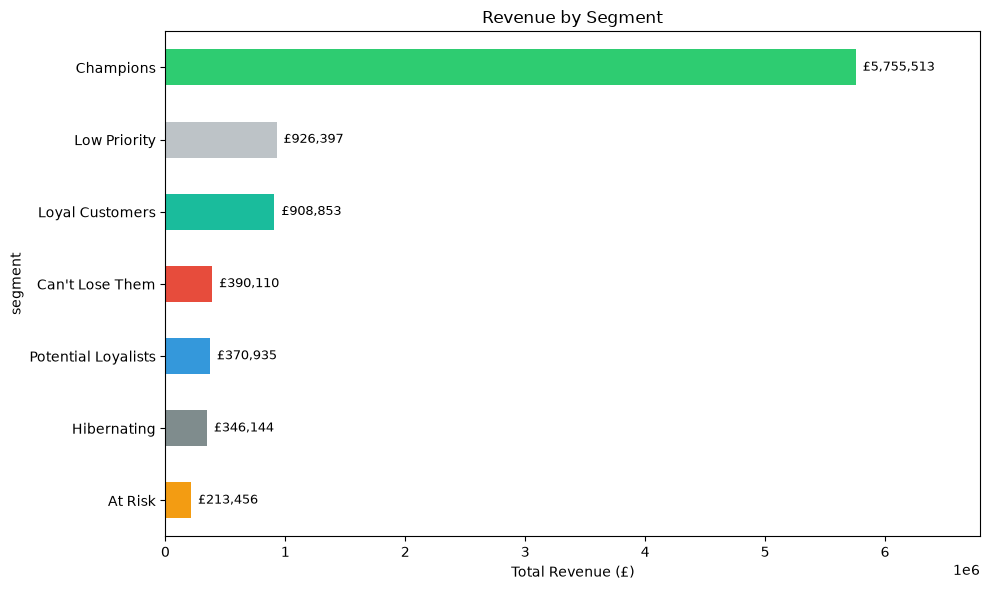

In [27]:
# Plot 1: Barh — Revenue by Segment
plt.figure(figsize=(10, 6))
rev_by_seg = rfm.groupby('segment')['monetary'].sum().sort_values(ascending=True)
rev_by_seg.plot(kind='barh', color=[colors[s] for s in rev_by_seg.index])

for i, v in enumerate(rev_by_seg.values):
    plt.text(v + max(rev_by_seg.values) * 0.01, i, f'£{v:,.0f}', va='center', fontsize=9)


plt.xlim(0, max(rev_by_seg.values) * 1.18)
plt.title('Revenue by Segment')
plt.xlabel('Total Revenue (£)')
plt.tight_layout()
plt.savefig('revenue_by_segment.png', dpi=200, bbox_inches='tight')
plt.show()   

<Figure size 500x800 with 0 Axes>

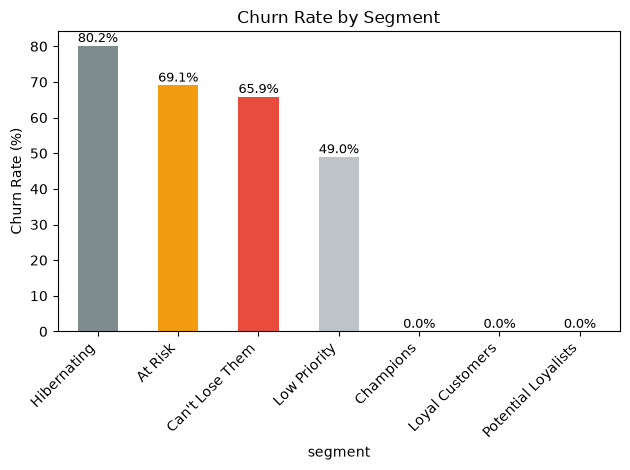

In [28]:
# Plot 2: Bar — Churn Rate by Segment 
plt.figure(figsize=(5, 8))
churn_sorted = churn_by_segment.sort_values('churn_rate', ascending=False)
churn_sorted.plot(kind='bar', x='segment', y='churn_rate',
                  legend=False,
                  color=[colors[s] for s in churn_sorted['segment']])

for i, v in enumerate(churn_sorted['churn_rate']):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=9)

plt.title('Churn Rate by Segment')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('churn_rate_by_segment.png', dpi=200, bbox_inches='tight')
plt.show()   

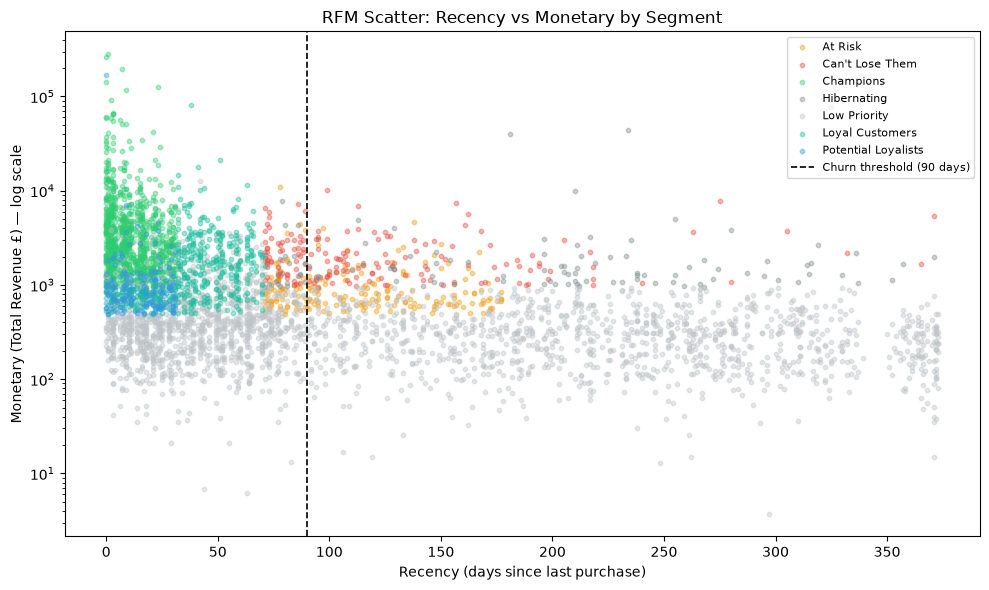

In [29]:
# Scatter: Recency vs Monetary
plt.figure(figsize=(10, 6))

for seg, group in rfm.groupby('segment'):
    plt.scatter(
        group['recency'],
        group['monetary'],
        label=seg,
        color=colors.get(seg, 'gray'),
        alpha=0.4,
        s=10
    )

plt.yscale('log')
plt.axvline(x=90, color='black', linestyle='--', linewidth=1.2,
            label='Churn threshold (90 days)')
plt.xlabel('Recency (days since last purchase)')
plt.ylabel('Monetary (Total Revenue £) — log scale')
plt.title('RFM Scatter: Recency vs Monetary by Segment')
plt.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.savefig('rfm_scatter.png', dpi=200, bbox_inches='tight')
plt.show()

## Connecting Python Script to PostgreSQL

In [30]:
!pip install psycopg2-binary sqlalchemy

In [31]:
from sqlalchemy import create_engine

# Step 1: Connect to PostgreSQL
# Replace placeholders with your actual details
username = "postgres"      # default user
password = "root" # the password you set during installation
host = "localhost"         # if running locally
port = "5432"              # default PostgreSQL port
database = "online_retail"    # the database you created in pgAdmin

engine = create_engine(f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}")

# Step 2: Load DataFrame into PostgreSQL
df.to_sql('transactions', engine, if_exists='replace', index=False)
rfm.to_sql('customers', engine, if_exists='replace', index=False)

print(f"Data successfully loaded into 'transactions' and 'customers' in database '{database}'.")   

Data successfully loaded into 'transactions' and 'customers' in database 'online_retail'.
